<div style="text-align: center; color:rgb(0, 0, 0); font-family: Arial, sans-serif; background-color:rgb(137, 200, 129); padding: 10px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2); line-height: 1.4;">

### **Series de Tiempo**
#### **Universidad Central**
#### Maestría en Analítica de Datos
#### Docente: Wilson Sandoval Rodriguez
##### wsandovalr@ucentral.edu.co

</div>

<div style="text-align: center; color: #5a8d84; font-family: Arial, sans-serif; background-color:rgb(244, 228, 200); padding: 10px; border-radius: 2px; box-shadow: 0 5px 8px rgba(0, 0, 0, 0.3); line-height: 1.2;">

# **01 · Fundamentos de series de tiempo** <a class="anchor" id="1"></a>

</div>

Antes de definir nada, vamos a mirar datos reales. La definición formal puede esperar unos minutos: primero, los datos.

## 0. 📈 El tiempo cambia la historia

La siguiente serie corresponde a la **inflación mensual en Colombia**, medida como la variación porcentual del Índice de Precios al Consumidor (IPC) mes a mes, desde enero de 2000 hasta mediados de 2023.

No se ha explicado todavía ningún concepto. Simplemente, observe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# --- Cargar el IPC mensual de Colombia y dejar nombres de columna simples ---
ipc = pd.read_excel(
    "https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/03_datos/compartidos/ipc_colombia_mensual.xlsx"
)
ipc.columns = ["periodo", "indice", "inflacion_anual", "inflacion_mensual", "inflacion_anio_corrido"]
ipc["fecha"] = pd.to_datetime(ipc["periodo"].astype(str), format="%Y%m")
ipc = ipc.set_index("fecha").drop(columns="periodo")

ipc.head()

,indice,inflacion_anual,inflacion_mensual,inflacion_anio_corrido
fecha,,,,
2000-01-01,40.30,8.25,1.29,1.29
2000-02-01,41.23,8.89,2.30,3.62
2000-03-01,41.93,9.73,1.71,5.39
2000-04-01,42.35,9.96,1.00,6.44
2000-05-01,42.57,10.00,0.52,7.00


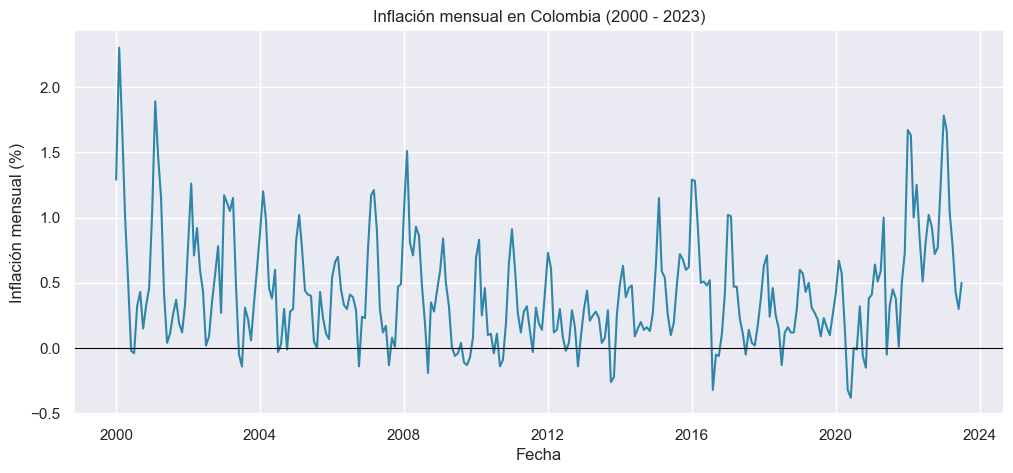

In [2]:
plt.plot(ipc.index, ipc["inflacion_mensual"], color="#2E86AB", linewidth=1.5)
plt.title("Inflación mensual en Colombia (2000 - 2023)")
plt.xlabel("Fecha")
plt.ylabel("Inflación mensual (%)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

<div style="background-color:#EAF7EE; border-left:5px solid #2E8B57; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🔍 Observe antes de continuar**

- ¿La inflación se mueve alrededor de un nivel estable, o cambia de nivel a lo largo del tiempo?
- ¿Hay periodos donde los valores altos parecen agruparse, y otros donde predominan valores bajos?
- ¿Identifica algún episodio que reconozca (por ejemplo, alrededor de 2022)? ¿Qué cree que lo explica?
- ¿Diría que el valor de un mes cualquiera ayuda a anticipar, aunque sea de forma aproximada, el valor del mes siguiente?

</div>

<div style="background-color:#F5EEFB; border-left:5px solid #8E44AD; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🤔 antes de continuar**

¿Podríamos analizar estos datos ignorando por completo el orden en que ocurrieron? ¿Cambiaría algo si tomáramos los mismos 283 valores y los organizáramos en un orden distinto?

</div>

### Los mismos datos, ordenados vs. mezclados

Para responder, hagamos el experimento: tomemos exactamente los mismos valores de inflación mensual y los mezclemos aleatoriamente, rompiendo el orden temporal. Los valores serán idénticos; solo cambia el orden.

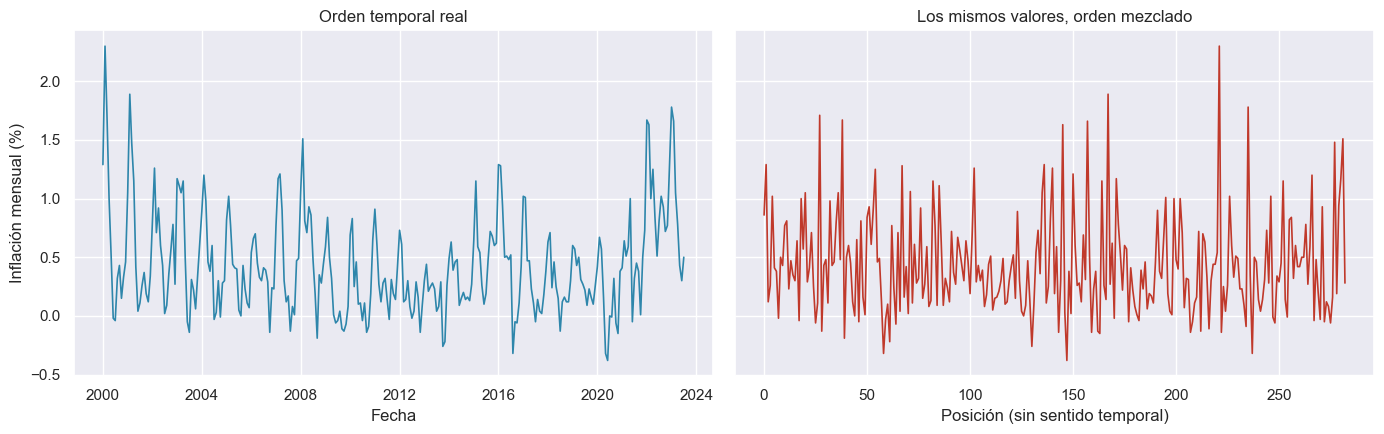

Media original:  0.4320   Media mezclada:  0.4320
Desv. estándar original: 0.4270   Desv. estándar mezclada: 0.4270


In [3]:
rng = np.random.default_rng(42)

original = ipc["inflacion_mensual"].values
mezclado = original.copy()
rng.shuffle(mezclado)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

axes[0].plot(ipc.index, original, color="#2E86AB", linewidth=1.2)
axes[0].set_title("Orden temporal real")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Inflación mensual (%)")

axes[1].plot(np.arange(len(mezclado)), mezclado, color="#C0392B", linewidth=1.2)
axes[1].set_title("Los mismos valores, orden mezclado")
axes[1].set_xlabel("Posición (sin sentido temporal)")

plt.tight_layout()
plt.show()

print(f"Media original:  {original.mean():.4f}   Media mezclada:  {mezclado.mean():.4f}")
print(f"Desv. estándar original: {original.std():.4f}   Desv. estándar mezclada: {mezclado.std():.4f}")

<div style="background-color:#EAF4FB; border-left:5px solid #2E86AB; padding:12px 16px; border-radius:4px; margin:8px 0;">

**💡 Idea clave**

La media y la desviación estándar son **exactamente iguales** en ambos casos: son los mismos 283 números.
Sin embargo, el panel izquierdo cuenta una historia (episodios de inflación alta, calma relativa, cambios de régimen) y el panel derecho no cuenta ninguna.

**En datos temporales, el orden contiene información que un resumen estadístico tradicional no captura.** Esa es la razón de ser de este curso.

</div>

## ¿Qué es una serie de tiempo?

## 1. ¿Qué hace especial a una serie de tiempo?

Formalmente, una **serie de tiempo** es una secuencia de observaciones indexadas por el tiempo:

$$\{y_t\}_{t \in T} = y_1, y_2, \ldots, y_T$$

donde $t$ es el índice temporal y $T$ es el conjunto (ordenado) de instantes en los que se observó la variable.

Hasta aquí, esto no es muy distinto de una columna cualquiera de una tabla. Lo que realmente distingue a una serie de tiempo es otra cosa:

> **Las observaciones no necesariamente son independientes entre sí. El presente puede estar relacionado con el pasado.**

Esa dependencia temporal —y no solo el hecho de tener una fecha asociada— es lo que obliga a tratar los datos temporales con herramientas distintas a las de un conjunto de datos tabular convencional.

| Datos tabulares tradicionales | Datos temporales |
|---|---|
| El orden de las filas suele ser irrelevante | El orden contiene información |
| Cada fila se analiza como una observación intercambiable | Una observación puede depender de las anteriores |
| Train/test puede dividirse aleatoriamente | Debe respetarse el orden temporal (más sobre esto en próximos notebooks) |
| Se asume frecuentemente independencia entre filas | La independencia rara vez es un supuesto razonable |

Una serie de tiempo puede clasificarse además según el tipo de proceso que la genera:

- **Determinística**: su comportamiento puede describirse completamente mediante una función matemática, sin componente aleatoria. Conociendo el modelo y las condiciones iniciales, el futuro se predice con exactitud.
- **Estocástica**: incorpora un componente aleatorio. Incluso conociendo el mecanismo generador, no es posible predecir el valor futuro con certeza absoluta — solo aproximarlo.

En la práctica, casi toda serie de tiempo con la que trabajará en analítica de datos es de naturaleza **estocástica**.

<div style="background-color:#F5EEFB; border-left:5px solid #8E44AD; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🤔 Microactividad 1 — Tabular vs. temporal**

Para cada variable, decida si el **orden** de las observaciones es importante para su análisis:

1. Ingresos anuales de 500 clientes distintos de un banco (una fila por cliente).
2. Temperatura registrada cada hora en una estación meteorológica.
3. Calificación de 1 000 reseñas de producto en un sitio de comercio electrónico (una fila por reseña, sin fecha).
4. Ventas diarias de una tienda durante los últimos tres años.

</div>

<details>
<summary>🔎 Comparar respuesta</summary>

1 y 3 son esencialmente **tabulares**: el orden de las filas no aporta información (podríamos reordenar los clientes o las reseñas sin perder nada).
2 y 4 son **series de tiempo**: el valor de una hora o un día está relacionado con los valores cercanos, y reordenarlos destruiría esa estructura — igual que en el ejercicio de la inflación mezclada.

</details>

## 2. 🌎 ¿Dónde aparecen las series de tiempo?

Prácticamente cualquier fenómeno que se mide repetidamente en el tiempo genera una serie de tiempo. Algunos ejemplos:

- **Economía y mercados**: inflación, desempleo, tasa de cambio, precio de una acción.
- **Demografía y salud**: número de nacimientos por año, pacientes atendidos por semana, casos de una enfermedad.
- **Medio ambiente**: temperatura, lluvia diaria, contaminación del aire.
- **Industria y comercio**: producción agrícola, ventas mensuales, demanda de un servicio.
- **Energía y transporte**: demanda eléctrica horaria, tráfico vehicular, pasajeros de una aerolínea.
- **Tecnología**: solicitudes por segundo a un servidor, sesiones activas de una aplicación.

<center><img src="https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/assets/images/01_fundamentos/economia.png" alt="economía" style="width:520px;"></center>

<center><img src="https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/assets/images/01_fundamentos/medioambiente.png" alt="medio ambiente" style="width:520px;"></center>

<div style="background-color:#FFF8E1; border-left:5px solid #C9971C; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🎯 En analítica real**

Algunos trabajos de grado de esta maestría que han usado series de tiempo como herramienta central:

- Pronóstico del precio en bolsa de la energía en Colombia.
- Predicción de ingresos para una empresa de servicios.
- Modelo ARIMA para los casos de COVID-19 en Colombia.
- Impacto de las precipitaciones mensuales sobre el caudal del río Cauca.
- Modelo VAR para pronosticar el costo de materiales de construcción en Colombia.
- Efecto de la tasa de cambio en la compra de software importado en América Latina.

Las series de tiempo no son un tema exclusivamente académico: son una herramienta de trabajo diaria en analítica aplicada.

</div>

### Una cuarta serie: el precio de una acción

Como último ejemplo de dominio, descarguemos el precio de cierre diario de una acción (AAPL) con `yfinance`. Esta celda depende de una API externa — si no hay conexión, o el proveedor cambia su respuesta, se genera automáticamente una serie sintética con la misma forma (una caminata aleatoria), para que el resto del notebook nunca dependa de que esta descarga funcione.

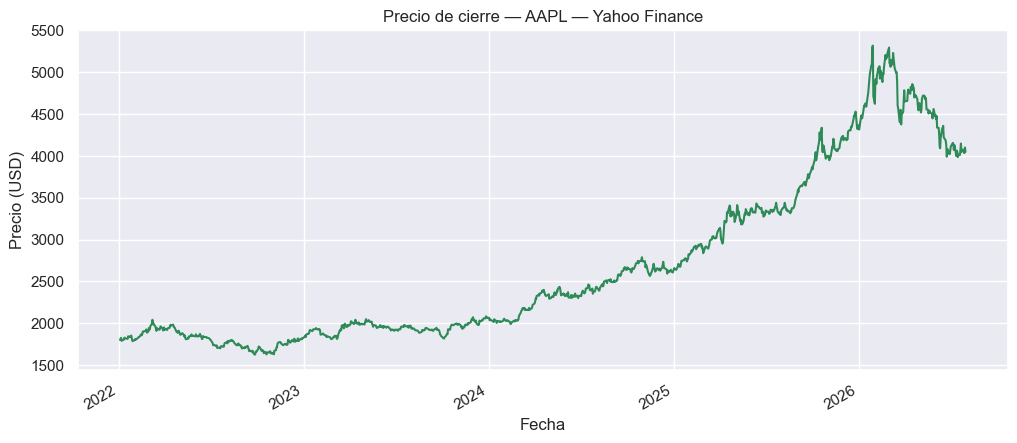

In [4]:
try:
    import yfinance as yf

    accion = yf.download("GC=F", start="2022-01-01", end="2026-08-03", progress=False)["Close"]
    accion = accion.squeeze().dropna()
    if accion.empty:
        raise ValueError("Descarga vacía")
    fuente = "AAPL — Yahoo Finance"
except Exception as e:
    print(f"No fue posible descargar datos de Yahoo Finance ({e}). Se usará una serie sintética de respaldo.")
    rng_precio = np.random.default_rng(0)
    fechas = pd.bdate_range(start="2022-01-01", end="2024-01-01")
    retornos = rng_precio.normal(loc=0.0004, scale=0.02, size=len(fechas))
    accion = pd.Series(150 * np.exp(np.cumsum(retornos)), index=fechas)
    fuente = "Serie sintética (caminata aleatoria, semilla fija)"

accion.plot(color="#2E8B57")
plt.title(f"Precio de cierre — {fuente}")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

<div style="background-color:#EAF7EE; border-left:5px solid #2E8B57; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🔍 Observe**

A diferencia de la inflación o la producción de café, el precio de una acción no muestra un patrón estacional obvio. ¿Ve algo parecido a una tendencia sostenida, o el comportamiento se asemeja más a un recorrido errático sin dirección clara?

</div>

## 3. ¿Qué queremos hacer con una serie temporal?

En analítica de datos, el trabajo con series de tiempo suele perseguir tres objetivos distintos. Aunque comparten herramientas, responden preguntas diferentes.

<center><img src="https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/assets/images/01_fundamentos/01_forecasting_concept.png" alt="forecasting" style="width:560px;"></center>

### 🔮 Forecasting

**Pregunta:** ¿qué podría ocurrir después?

Ejemplos: ventas del próximo mes, demanda energética de mañana, número de pacientes esperados la próxima semana.

<center><img src="https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/assets/images/01_fundamentos/02_nowcasting_concept.png" alt="nowcasting" style="width:560px;"></center>

### ⚡ Nowcasting

**Pregunta:** ¿qué está ocurriendo *ahora*, cuando el dato oficial todavía no está disponible?

Ejemplo: el PIB oficial de un trimestre se publica con semanas o meses de retraso. El nowcasting combina indicadores disponibles en tiempo real (consumo de energía, tráfico, transacciones con tarjeta) para estimar el crecimiento económico *actual*, antes de que exista una cifra oficial.

<center><img src="https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/assets/images/01_fundamentos/03_anomaly_detection_concept.png" alt="detección de anomalías" style="width:560px;"></center>

### 🚨 Detección de anomalías

**Pregunta:** ¿está ocurriendo algo inusual en este momento?

Ejemplos: una transacción posiblemente fraudulenta, la falla de un sensor industrial, un aumento inesperado de demanda, un comportamiento epidemiológico atípico.

| Objetivo | Pregunta central |
|---|---|
| 🔮 Forecasting | ¿Qué ocurrirá después? |
| ⚡ Nowcasting | ¿Qué está ocurriendo ahora? |
| 🚨 Detección de anomalías | ¿Está ocurriendo algo inesperado? |

<div style="background-color:#F5EEFB; border-left:5px solid #8E44AD; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🤔 Microactividad 2 — Forecasting, nowcasting o anomalías**

Clasifique cada situación:

1. Un banco central quiere estimar el crecimiento del PIB del trimestre actual, que solo se conocerá oficialmente dentro de 8 semanas.
2. Una cadena de supermercados quiere estimar cuántas unidades de un producto venderá en diciembre.
3. Un sistema de tarjetas de crédito detecta una compra con un patrón de gasto muy distinto al habitual del cliente.

</div>

<details>
<summary>🔎 Comparar respuesta</summary>

1. Nowcasting (estimar el presente sin el dato oficial). 2. Forecasting (predecir un valor futuro). 3. Detección de anomalías (identificar un comportamiento atípico).

</details>

## 4. 🧩 Anatomía de una serie temporal

Muchas series de tiempo del mundo real pueden entenderse como la superposición de varios patrones reconocibles. Antes de nombrarlos, observemos una serie simulada.

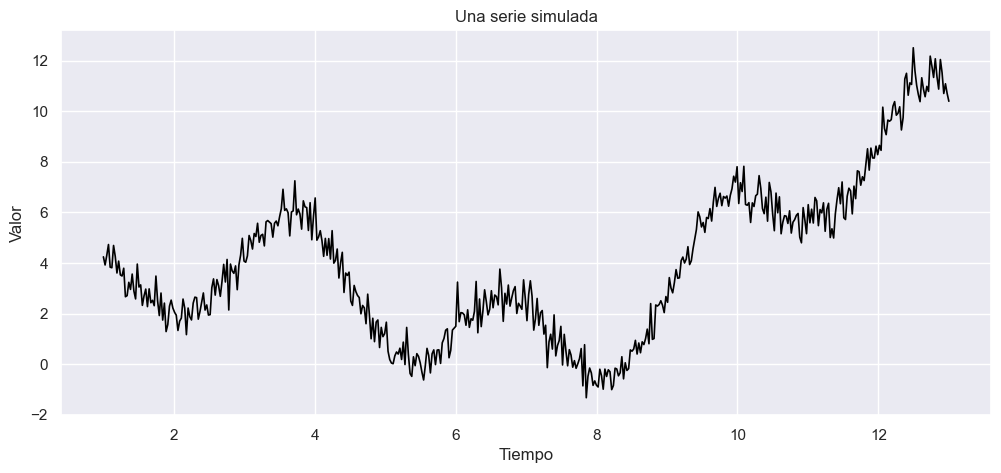

In [5]:
np.random.seed(42)
t = np.linspace(1, 13, 500)

tendencia = 0.5 * t
estacionalidad = 2 * np.sin(2 * np.pi * t / 3)
ciclo = 3 * np.sin(2 * np.pi * t / 10)
irregular = np.random.normal(0, 0.5, len(t))

serie = tendencia + estacionalidad + ciclo + irregular

plt.plot(t, serie, color="black", linewidth=1.2)
plt.title("Una serie simulada")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

<div style="background-color:#EAF7EE; border-left:5px solid #2E8B57; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🔍 Observe**

¿Reconoce algún movimiento de largo plazo? ¿Algún patrón que se repite a intervalos regulares? ¿Fluctuaciones más lentas y menos regulares que las anteriores? ¿Ruido que no encaja en ninguna de las anteriores?

</div>

Ahora veamos la misma serie, descompuesta y etiquetada:

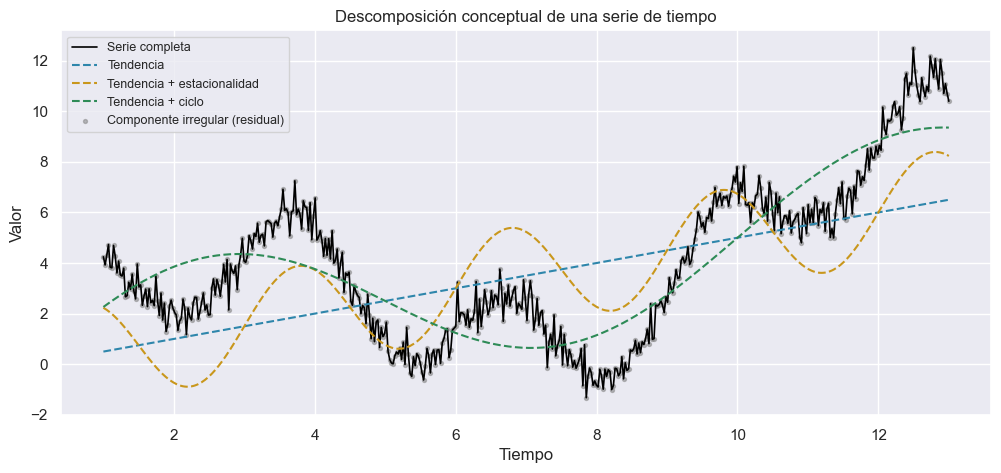

In [6]:
plt.plot(t, serie, label="Serie completa", color="black", linewidth=1.2)
plt.plot(t, tendencia, label="Tendencia", linestyle="--", color="#2E86AB")
plt.plot(t, tendencia + estacionalidad, label="Tendencia + estacionalidad", linestyle="--", color="#C9971C")
plt.plot(t, tendencia + ciclo, label="Tendencia + ciclo", linestyle="--", color="#2E8B57")
plt.scatter(t, serie, s=8, label="Componente irregular (residual)", color="gray", alpha=0.5)

plt.title("Descomposición conceptual de una serie de tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend(fontsize=9)
plt.show()

### Tendencia ($T_t$)

Movimiento de largo plazo de la serie: el nivel general sube, baja o se mantiene relativamente estable a lo largo de varios periodos, ignorando fluctuaciones de corto plazo.

### Estacionalidad ($S_t$)

Comportamiento que se repite en intervalos **fijos y conocidos**, asociados al calendario o a la frecuencia de observación. Ejemplos: ventas más altas en diciembre, consumo eléctrico que sube cada tarde, más pasajeros aéreos en temporada vacacional.

### Ciclos

Fluctuaciones más largas que la estacionalidad, pero **sin periodicidad fija**. Un ciclo económico de expansión y recesión puede durar 3 años en una ocasión y 7 en otra — a diferencia de la estacionalidad, no se puede calendarizar de antemano.

### Componente irregular / residual ($R_t$)

Lo que queda después de retirar tendencia, estacionalidad y ciclo: variación que no se explica fácilmente por los demás componentes.

<div style="background-color:#E8F6F6; border-left:5px solid #17847E; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🧪 Microactividad 3 — Experimente**

En la celda de la serie simulada, cambie `2 * np.sin(2 * np.pi * t / 3)` por `2 * np.sin(2 * np.pi * t / 6)` y vuelva a ejecutar.

¿El periodo de la estacionalidad aumentó o disminuyó? ¿Qué parámetro del `np.sin` controla la duración de un ciclo estacional?

</div>

## 5. ⏱️ El tiempo también tiene una escala

Antes de analizar cualquier serie, hay tres preguntas que siempre deben responderse:

### Frecuencia

Cada cuánto se observa la serie: segundo, minuto, hora, día, semana, mes, trimestre, año. En `pandas`, la frecuencia se expresa con alias como `"D"` (diaria), `"W"` (semanal), `"ME"` (fin de mes), `"QE"` (fin de trimestre) o `"YE"` (fin de año) — los mismos que ya usamos al construir el índice del IPC.

### Granularidad

Qué tan detallada es la información dentro de esa frecuencia. Una serie de ventas "diarias" agregadas a nivel de toda una cadena tiene menor granularidad que la misma serie desagregada por tienda y por producto.

### Horizonte

Cuántos periodos hacia adelante se desea pronosticar.

<div style="background-color:#FDEEEE; border-left:5px solid #C0392B; padding:12px 16px; border-radius:4px; margin:8px 0;">

**⚠️ Error frecuente**

Pronosticar "12 periodos" no significa lo mismo en todas las series. 12 periodos en datos **diarios** son aproximadamente 12 días. 12 periodos en datos **mensuales** son aproximadamente 1 año. El horizonte siempre debe interpretarse junto con la frecuencia.

</div>

### Supuestos al indexar en el tiempo

Cuando tratamos una serie como equiespaciada en el tiempo, estamos asumiendo que:

- las observaciones consecutivas están igualmente espaciadas (cada hora, cada día, cada mes, según la frecuencia elegida),
- es válido representar ese tiempo mediante un índice discreto $t = 1, 2, 3, \ldots$

En la práctica, esto casi nunca se cumple de forma perfecta (un mes no dura siempre lo mismo, un sensor puede fallar un día) — se trata de una aproximación razonable, no de un hecho exacto. Vale la pena tenerlo presente porque casi todos los métodos que veremos en el curso parten de este supuesto.

<div style="background-color:#F5EEFB; border-left:5px solid #8E44AD; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🤔 Microactividad 4 — Frecuencia y horizonte**

Una empresa observa su demanda **semanalmente** y quiere pronosticar 24 periodos hacia adelante.

¿A cuántos meses equivale aproximadamente ese horizonte? ¿Le parece un horizonte de corto, mediano o largo plazo?

</div>

<details>
<summary>🔎 Comparar respuesta</summary>

24 semanas ≈ 5.5 meses. Para una serie semanal esto suele considerarse un horizonte de mediano plazo: bastante más incierto que pronosticar el mismo número de periodos (24) en una serie diaria (≈ 24 días, corto plazo).

</details>

## 6. 🔎 Antes de modelar: aprender a mirar

Trabajemos ahora con una segunda serie: la **producción mensual de café en Colombia** (miles de sacos de 60 kg de café verde equivalente). Es una serie con estacionalidad marcada y una historia larga — ideal para practicar la exploración inicial.

In [7]:
cafe = pd.read_excel(
    "https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/03_datos/compartidos/produccion_cafe.xlsx"
)
cafe.columns = ["fecha", "produccion"]
cafe["fecha"] = pd.to_datetime(cafe["fecha"])
cafe = cafe.set_index("fecha")

cafe.head()

,produccion
fecha,
2000-01-01,658.0
2000-02-01,740.0
2000-03-01,592.0
2000-04-01,1055.0
2000-05-01,1114.0


In [8]:
cafe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 313 entries, 2000-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   produccion  313 non-null    float64
dtypes: float64(1)
memory usage: 4.9 KB


In [9]:
cafe.index

DatetimeIndex(['2000-01-01', '2000-02-01', '2000-03-01', '2000-04-01',
               '2000-05-01', '2000-06-01', '2000-07-01', '2000-08-01',
               '2000-09-01', '2000-10-01',
               ...
               '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01',
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01'],
              dtype='datetime64[ns]', name='fecha', length=313, freq=None)

In [10]:
cafe.describe()

,produccion
count,313.000000
mean,980.703350
std,263.829037
min,345.000000
25%,788.000000
50%,981.000000
75%,1151.000000
max,1798.230552


Con esta primera mirada tabular ya sabemos el rango de fechas, si hay datos faltantes y el orden de magnitud de la serie. Ahora, grafiquemos.

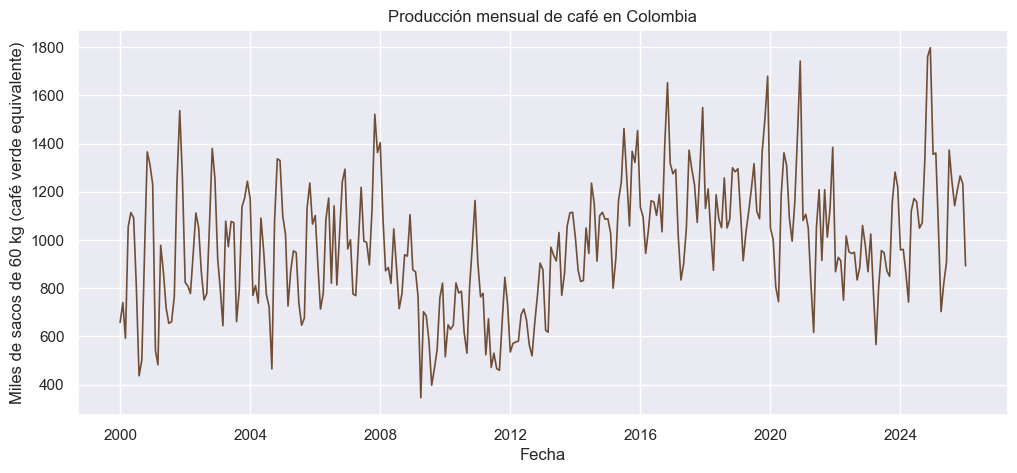

In [11]:
plt.plot(cafe.index, cafe["produccion"], color="#6F4E37", linewidth=1.2)
plt.title("Producción mensual de café en Colombia")
plt.xlabel("Fecha")
plt.ylabel("Miles de sacos de 60 kg (café verde equivalente)")
plt.show()

`pandas` y `plotly` ofrecen atajos útiles: `pandas` para una vista rápida, `plotly` cuando conviene explorar la serie de forma interactiva (zoom, hover con el valor exacto).

In [12]:
fig = px.line(cafe, x=cafe.index, y="produccion", title="Producción mensual de café — vista interactiva")
fig.update_layout(xaxis_title="Fecha", yaxis_title="Miles de sacos de 60 kg")
fig.show()

<div style="background-color:#EAF7EE; border-left:5px solid #2E8B57; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🔍 Observe**

Al mirar la serie de café, pregúntese:

- ¿Hay tendencia? ¿Es creciente, decreciente, o cambia de dirección en distintos periodos?
- ¿Hay un patrón que se repite cada 12 meses (estacionalidad)?
- ¿La variabilidad de la serie es similar al inicio y al final, o cambia con el tiempo?
- ¿Hay datos faltantes o huecos en la serie?
- ¿Hay valores que llaman la atención por ser inusualmente altos o bajos?
- ¿Hay algún punto donde el comportamiento de la serie parece cambiar de forma abrupta (cambio estructural)?

</div>

<div style="background-color:#EAF4FB; border-left:5px solid #2E86AB; padding:12px 16px; border-radius:4px; margin:8px 0;">

**💡 Idea clave**

En series de tiempo, visualizar no es decoración. Es parte del análisis: muchas veces un gráfico revela en segundos algo que ningún estadístico resumen (media, varianza) puede mostrar por sí solo — como ya vimos con el experimento de mezclar la inflación.

</div>

## 7. Transformaciones básicas

La serie de café tiene una tendencia creciente marcada. Para estudiar mejor su dinámica de corto plazo, suele ser útil transformarla.

### Primera diferencia

**Problema:** la tendencia domina visualmente la serie y dificulta ver los movimientos de un periodo a otro.

**Transformación:**

$$\Delta y_t \equiv y_t - y_{t-1}$$

**Interpretación:** cada valor representa el cambio absoluto de la producción respecto al mes anterior. La primera diferencia suele eliminar la tendencia y conservar las oscilaciones estacionales.

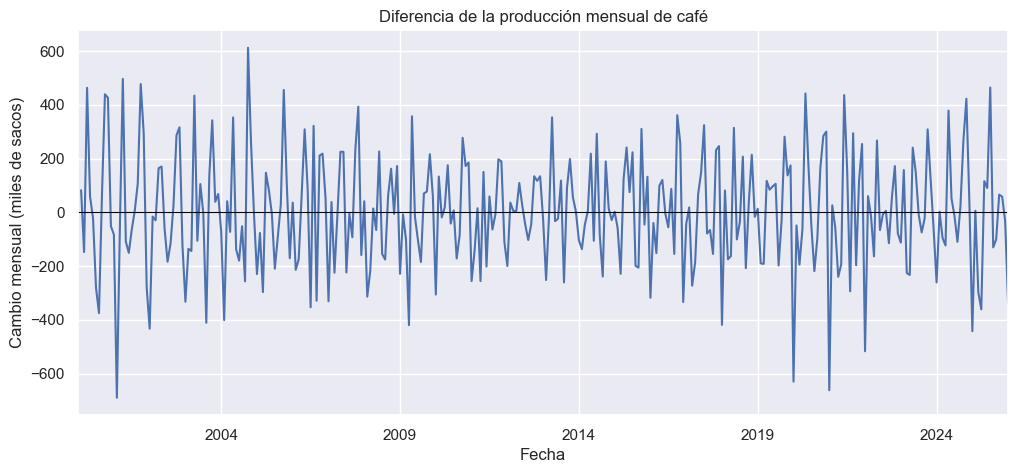

In [13]:
cafe["produccion"].diff(1).plot(title="Diferencia de la producción mensual de café")
plt.xlabel("Fecha")
plt.ylabel("Cambio mensual (miles de sacos)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

### Tasa de crecimiento

**Problema:** una misma diferencia absoluta significa algo distinto según el nivel de la serie (por ejemplo, un cambio de 100 mil sacos no pesa igual cuando la producción es de 600 que cuando es de 1 800).

**Transformación:**

$$\Delta\% y_t \equiv \frac{y_t - y_{t-1}}{y_{t-1}} \times 100$$

**Interpretación:** cada valor es el cambio porcentual respecto al mes anterior, comparable entre distintos niveles de la serie.

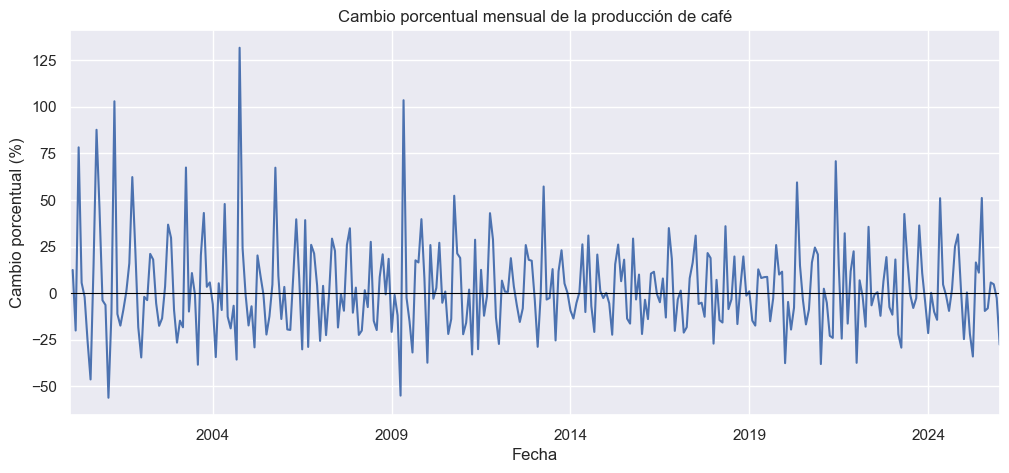

In [14]:
cafe["produccion"].pct_change(1).mul(100).plot(title="Cambio porcentual mensual de la producción de café")
plt.xlabel("Fecha")
plt.ylabel("Cambio porcentual (%)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

### Diferencia estacional

**Problema:** la diferencia de un mes contra el anterior todavía mezcla el efecto estacional (por ejemplo, abril siempre produce distinto que marzo) con el cambio real de nivel de la serie.

**Transformación:** comparar cada mes contra el mismo mes del año anterior:

$$\Delta_{12} y_t \equiv y_t - y_{t-12}$$

**Interpretación:** al comparar diciembre con diciembre (o cualquier mes con el mismo mes del año previo), el efecto estacional se cancela y lo que queda refleja principalmente el crecimiento interanual.

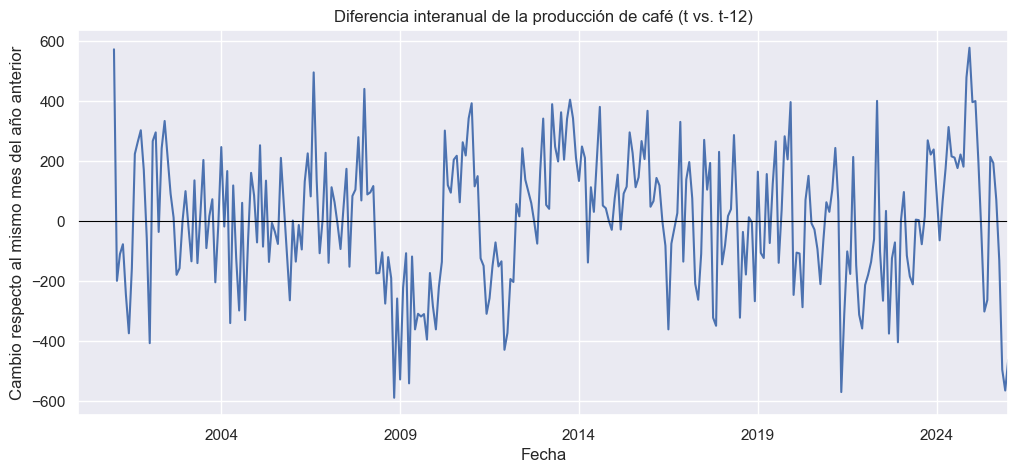

In [15]:
cafe["produccion"].diff(12).plot(title="Diferencia interanual de la producción de café (t vs. t-12)")
plt.xlabel("Fecha")
plt.ylabel("Cambio respecto al mismo mes del año anterior")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

In [22]:
cafe["produccion"]

fecha
2000-01-01     658.000000
2000-02-01     740.000000
2000-03-01     592.000000
2000-04-01    1055.000000
2000-05-01    1114.000000
                 ...     
2025-09-01    1142.412575
2025-10-01    1208.086500
2025-11-01    1266.069638
2025-12-01    1233.423169
2026-01-01     892.727668
Name: produccion, Length: 313, dtype: float64

In [23]:
cafe["produccion"].diff(12)

fecha
2000-01-01           NaN
2000-02-01           NaN
2000-03-01           NaN
2000-04-01           NaN
2000-05-01           NaN
                 ...    
2025-09-01     71.179167
2025-10-01   -131.068508
2025-11-01   -495.339884
2025-12-01   -564.807382
2026-01-01   -463.039485
Name: produccion, Length: 313, dtype: float64

<div style="background-color:#F5EEFB; border-left:5px solid #8E44AD; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🤔 Microactividad 5 — Interpretar una diferencia**

En el gráfico de la diferencia interanual (`diff(12)`), identifique un periodo donde el valor sea claramente positivo y sostenido. ¿Qué significa eso en términos de la producción de café respecto al año anterior? Ahora identifique un periodo con valores negativos: ¿qué está ocurriendo ahí?

</div>

<details>
<summary>🔎 Comparar respuesta</summary>

Un tramo con `diff(12)` positivo y sostenido indica que, mes tras mes, la producción está siendo consistentemente mayor que la del mismo mes del año anterior — es decir, la serie está en una fase de crecimiento interanual. Un tramo negativo indica lo contrario: la producción está cayendo frente al año anterior, incluso si en términos absolutos (`diff(1)`) algunos meses individuales suban.

</details>

## 8. 🧩 Descomponer para comprender

Ya identificamos visualmente tendencia, estacionalidad y componente irregular. El siguiente paso es formalizar cómo se combinan.

### Modelo aditivo

$$Y_t = T_t + S_t + R_t$$

Apropiado cuando la **amplitud** de las fluctuaciones estacionales se mantiene aproximadamente constante a lo largo del tiempo: los picos y valles conservan una altura similar sin importar el nivel de la serie.

### Modelo multiplicativo

$$Y_t = T_t \times S_t \times R_t$$

Apropiado cuando la amplitud de la estacionalidad **crece o decrece junto con el nivel** de la serie: los picos son cada vez más pronunciados a medida que la serie crece.

*(Usamos $T_t$, $S_t$, $R_t$ — tendencia, estacional, residual/irregular — la misma notación que usa `statsmodels`, la librería que emplearemos para descomponer series.)*

Comparemos ambos casos con datos simulados donde controlamos exactamente cómo se genera la estacionalidad.

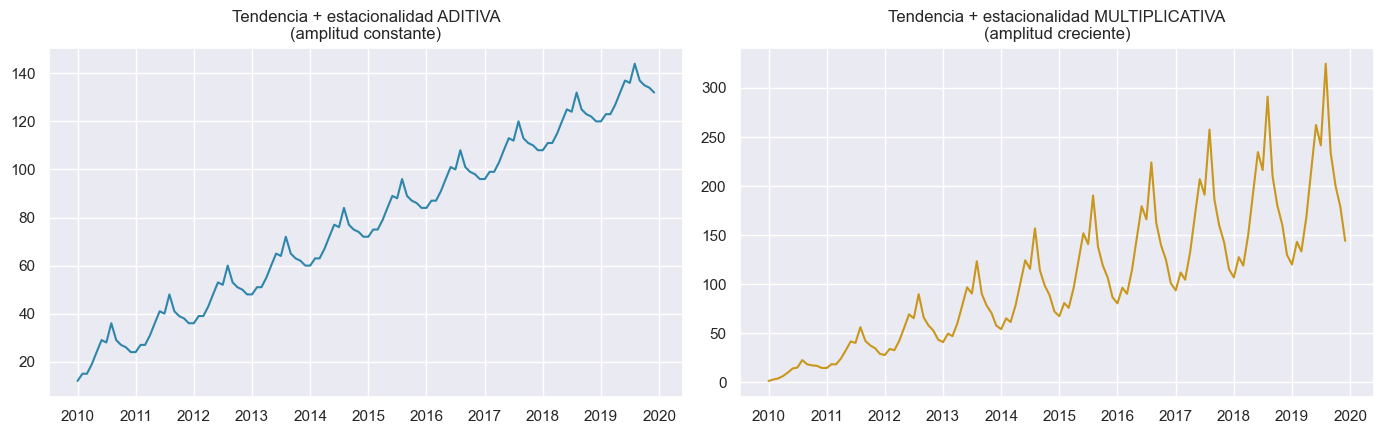

In [16]:
# Tendencia lineal + estacionalidad ADITIVA (amplitud constante)
patron_aditivo = [11, 13, 12, 15, 19, 23, 21, 28, 20, 17, 15, 12]
x = np.arange(1, 121)

valores_aditivo = [val + patron_aditivo[i % 12] for i, val in enumerate(x)]
df_aditivo = pd.DataFrame({"y": valores_aditivo}, index=pd.date_range("2010-01-01", freq="MS", periods=120))

# Tendencia lineal + estacionalidad MULTIPLICATIVA (amplitud creciente)
patron_multiplicativo = [1.1, 1.3, 1.2, 1.5, 1.9, 2.3, 2.1, 2.8, 2.0, 1.7, 1.5, 1.2]
valores_multiplicativo = [val * patron_multiplicativo[i % 12] for i, val in enumerate(x)]
df_multiplicativo = pd.DataFrame({"y": valores_multiplicativo}, index=pd.date_range("2010-01-01", freq="MS", periods=120))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(df_aditivo["y"], color="#2E86AB")
axes[0].set_title("Tendencia + estacionalidad ADITIVA\n(amplitud constante)")
axes[1].plot(df_multiplicativo["y"], color="#C9971C")
axes[1].set_title("Tendencia + estacionalidad MULTIPLICATIVA\n(amplitud creciente)")
plt.tight_layout()
plt.show()

<div style="background-color:#EAF7EE; border-left:5px solid #2E8B57; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🔍 Observe**

En el panel izquierdo, los picos estacionales tienen prácticamente la misma altura del principio al final. En el panel derecho, los picos son cada vez más grandes a medida que la serie crece — esa es la firma visual de una estacionalidad multiplicativa.

</div>

### Descomposición en acción

La función `seasonal_decompose()` de `statsmodels` toma la serie y un `model` (`'additive'` o `'multiplicative'`) y separa $T_t$, $S_t$ y $R_t$ automáticamente.

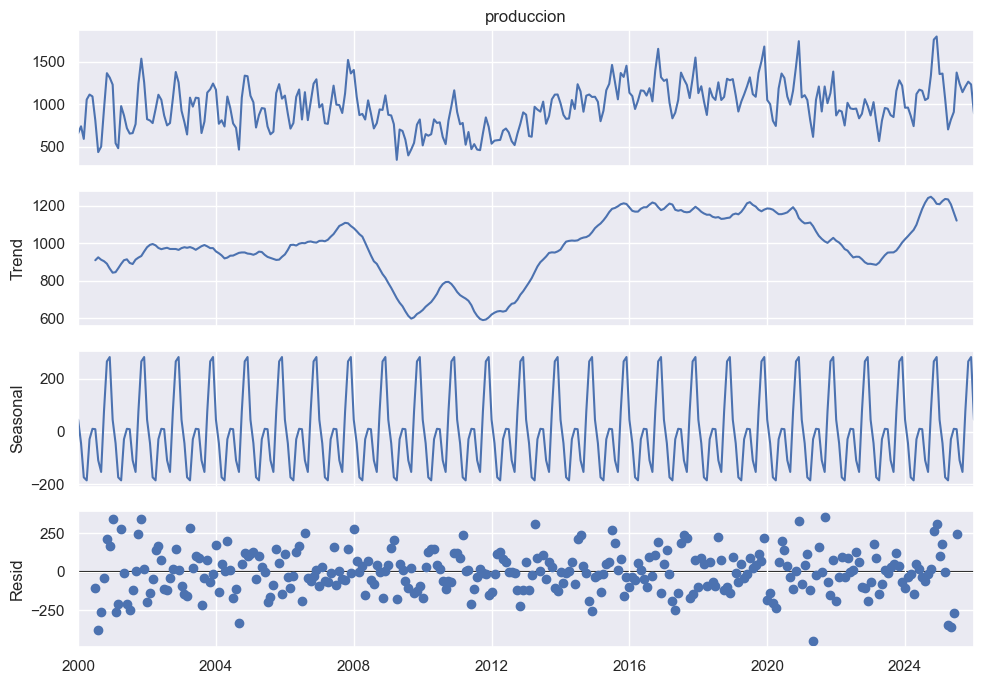

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp_cafe = seasonal_decompose(cafe["produccion"], model="additive", period=12)
fig = decomp_cafe.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

<div style="background-color:#E8F6F6; border-left:5px solid #17847E; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🧪 Microactividad 6 — Experimente**

Cambie `model="additive"` por `model="multiplicative"` en la celda anterior y vuelva a ejecutar. Observe el panel `resid`: ¿en cuál de los dos modelos el residuo parece más parecido a ruido sin estructura, y en cuál todavía se nota un patrón? Recuerde lo observado en la sección 6 sobre el cambio de variabilidad de la serie de café a lo largo del tiempo.

</div>

## 9. Medias móviles y estimación de tendencia

`seasonal_decompose()` no calcula la tendencia por arte de magia: internamente aplica una **media móvil**. Vale la pena entender qué hace ese paso, porque es la base de la descomposición y de muchas técnicas de suavizamiento.

Una **media móvil de orden $m$** reemplaza cada observación por el promedio de sus $m$ vecinas más cercanas. Al promediar, las fluctuaciones de corto plazo (estacionalidad, ruido) se cancelan parcialmente y queda expuesto el movimiento de más largo plazo: la tendencia.

### El problema del orden par

Si $m$ es impar (por ejemplo 5), la media móvil se centra de forma natural: el promedio de $x_{t-2}, \ldots, x_{t+2}$ queda asociado exactamente al instante $t$.

Si $m$ es **par** (por ejemplo, 4 trimestres al año), no existe un punto central natural: el promedio de $x_{t-2}, x_{t-1}, x_t, x_{t+1}$ queda "entre" $t-1$ y $t$. La solución es **centrar** la media móvil promediando dos medias móviles consecutivas de orden 4:

$$\frac{1}{2}\left[\frac{1}{4}(x_{t-2}+x_{t-1}+x_t+x_{t+1}) + \frac{1}{4}(x_{t-1}+x_t+x_{t+1}+x_{t+2})\right] = \frac{1}{8}x_{t-2}+\frac{1}{4}x_{t-1}+\frac{1}{4}x_t+\frac{1}{4}x_{t+1}+\frac{1}{8}x_{t+2}$$

Este promedio doble ("2×4-MA") sí queda correctamente centrado en $t$, y es exactamente lo que usa `statsmodels` para estimar la tendencia de una serie con periodo estacional 4 (trimestral).

### De la tendencia al componente estacional: un ejemplo completo y verificado

Trabajemos con una tercera serie: la **producción trimestral de cerveza** (un conjunto de datos clásico en la literatura de pronóstico), para ver el procedimiento completo paso a paso — y comprobar que efectivamente reproduce lo que entrega `seasonal_decompose()`.

In [18]:
beerprod = np.loadtxt(
    "https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/03_datos/01_fundamentos/produccion_cerveza.dat"
).flatten()

cerveza = pd.Series(
    beerprod,
    index=pd.date_range(start="2000-01-01", periods=len(beerprod), freq="QE"),
    name="produccion",
)
cerveza.head(8)

2000-03-31    284.4
2000-06-30    212.8
2000-09-30    226.9
2000-12-31    308.4
2001-03-31    262.0
2001-06-30    227.9
2001-09-30    236.1
2001-12-31    320.4
Freq: QE-DEC, Name: produccion, dtype: float64

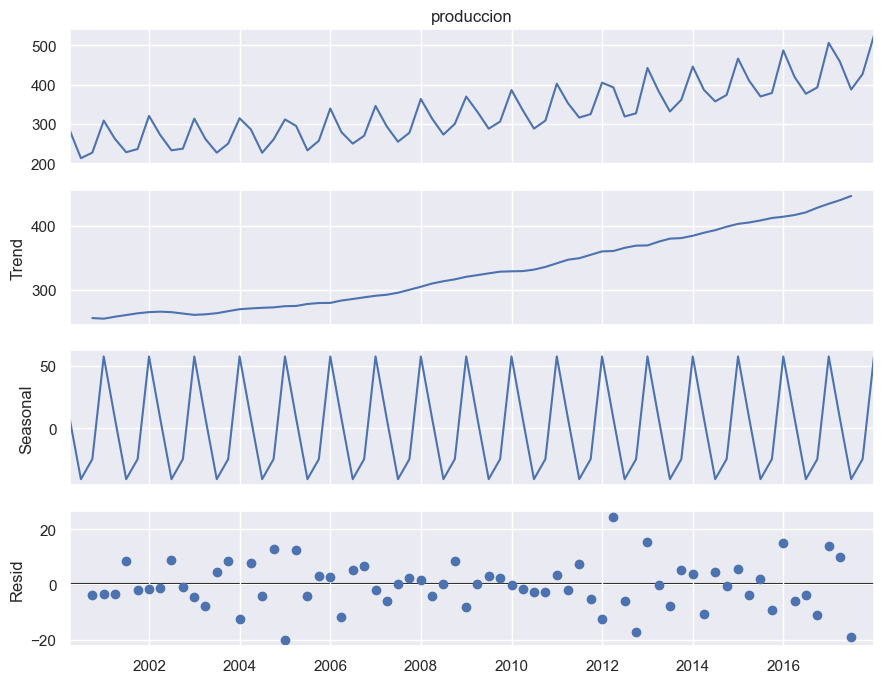

In [19]:
decomp_cerveza = seasonal_decompose(cerveza, model="additive", period=4)

fig = decomp_cerveza.plot()
fig.set_size_inches(9, 7)
plt.tight_layout()
plt.show()

**Paso 1 — Tendencia:** promedio móvil centrado de orden 4 (2×4-MA), tal como se definió arriba. Por eso los dos primeros y los dos últimos valores de la tendencia son `NaN`: no hay suficientes vecinos para centrar el promedio.

**Paso 2 — Serie sin tendencia:** $y_t - T_t$

**Paso 3 — Promediar por trimestre:** agrupar todos los valores de $y_t - T_t$ que caen en Q1, todos los que caen en Q2, etc., y promediar cada grupo.

**Paso 4 — Ajustar para que sumen cero:** restar a cada promedio trimestral la media de los cuatro promedios, de modo que $S_{Q1}+S_{Q2}+S_{Q3}+S_{Q4}=0$. Esto evita que el componente estacional "absorba" parte del nivel de la serie, que le corresponde a la tendencia.

In [20]:
detrend = cerveza - decomp_cerveza.trend
promedio_por_trimestre = detrend.groupby(detrend.index.quarter).mean()
ajuste = promedio_por_trimestre - promedio_por_trimestre.mean()

comparacion = pd.DataFrame({
    "promedio detrend por trimestre": promedio_por_trimestre,
    "estacional ajustado (nuestro cálculo)": ajuste,
    "estacional de statsmodels": decomp_cerveza.seasonal.iloc[:4].values,
})
comparacion.index.name = "trimestre"
comparacion

,promedio detrend por trimestre,estacional ajustado (nuestro cálculo),estacional de statsmodels
trimestre,,,
1,7.677941,7.896324,7.896324
2,-40.897059,-40.678676,-40.678676
3,-24.869118,-24.650735,-24.650735
4,57.214706,57.433088,57.433088


<div style="background-color:#EAF4FB; border-left:5px solid #2E86AB; padding:12px 16px; border-radius:4px; margin:8px 0;">

**💡 Idea clave**

Nuestro cálculo manual — media móvil centrada, resta de tendencia, promedio por trimestre y ajuste a suma cero — coincide exactamente con la columna `seasonal` que entrega `statsmodels`. No hay magia: la descomposición automática hace, paso a paso, lo mismo que acabamos de hacer a mano.

</div>

## 10. 🎯 ¿Qué queremos pronosticar realmente?

Antes de pensar en un modelo, un proyecto de forecasting serio debe responder preguntas mucho más básicas:

- ¿Qué variable queremos predecir exactamente?
- ¿A qué nivel de agregación? ¿Producto, categoría o empresa completa? ¿Tienda, ciudad o país?
- ¿Cada cuánto se observa la serie (frecuencia)?
- ¿Cuánto tiempo hacia adelante necesitamos pronosticar (horizonte)?
- ¿Cada cuánto se actualizará el pronóstico?

Estas decisiones condicionan qué datos se necesitan, qué modelos son viables y qué tan útil será el resultado para quien tome decisiones con él.

<div style="background-color:#FDEEEE; border-left:5px solid #C0392B; padding:12px 16px; border-radius:4px; margin:8px 0;">

**⚠️ Error frecuente**

Empezar preguntando "¿qué modelo uso?" antes de definir correctamente el problema. El modelo es una de las últimas decisiones del proceso, no la primera.

</div>

## 11. 🔄 Flujo de un proyecto de forecasting

**Problema → Datos → Exploración → Preparación → Modelamiento → Evaluación → Pronóstico → Monitoreo**

#### 🧩 1. Definición del problema
Qué se va a pronosticar, para qué, y quién usará el resultado. Requiere entender el contexto y hablar con quienes tomarán decisiones a partir del pronóstico.

#### 📊 2. Recopilación de datos
Reunir el histórico disponible y el conocimiento experto del fenómeno. No siempre habrá datos suficientes o de buena calidad — evaluar eso es parte del trabajo.

#### 🔍 3. Exploración
Visualizar la serie para identificar tendencia, estacionalidad, ciclos y valores atípicos — exactamente lo que hicimos en la sección 6.

#### ⚙️ 4. Preparación
Limpiar, transformar y estructurar los datos: tratar faltantes, aplicar diferencias o transformaciones si es necesario, definir la frecuencia de trabajo.

#### 🧮 5. Modelamiento
Elegir y ajustar uno o varios modelos adecuados a los datos disponibles y al horizonte requerido, comparando su desempeño.

#### 📈 6. Evaluación y pronóstico
Medir qué tan bien predice el modelo con datos que no vio durante el ajuste, y generar el pronóstico final.

#### 🛰️ 7. Monitoreo
Una vez el pronóstico está en uso, verificar que siga siendo razonable a medida que llegan datos nuevos.

👉 Este proceso es **iterativo**: si el modelo funciona mal, es común volver a revisar los datos, las transformaciones o incluso la definición original del problema.

## 12. Una idea fundamental: estacionariedad

Miremos dos series antes de definir nada formalmente.

<center><img src="https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/assets/images/06_estacionariedad/estacionaria_vs_no_estacionaria.jpg" alt="estacionaria vs no estacionaria" style="width:620px;"></center>

<div style="background-color:#F5EEFB; border-left:5px solid #8E44AD; padding:12px 16px; border-radius:4px; margin:8px 0;">

**🤔 Piense**

¿Cuál de las dos series parece mantener un comportamiento estadístico más estable en el tiempo — un nivel alrededor del cual oscila y una dispersión similar en todos los tramos? ¿Cuál cambia claramente de nivel o de variabilidad?

</div>

<center><img src="https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/assets/images/06_estacionariedad/no_estacionariedad.jpg" alt="no estacionariedad" style="width:520px;"></center>

Formalmente, una serie de tiempo $y_t$ (vista como un proceso estocástico) es **débilmente estacionaria** si:

* $E(y_t)$ es constante para todo $t$ (media estable),
* $Var(y_t)$ es constante para todo $t$ (varianza estable),
* $Cov(y_t, y_{t+h})$ depende únicamente del rezago $h$, y no del instante $t$ (la dependencia temporal es estable).

La condición de **estacionariedad fuerte** es más exigente: exige que la distribución conjunta de $Y_{t_1}, \ldots, Y_{t_n}$ sea la misma que la de $Y_{t_1-k}, \ldots, Y_{t_n-k}$ para cualquier desplazamiento $k$ — es decir, toda la distribución (no solo media, varianza y covarianza) depende únicamente de las diferencias de tiempo entre observaciones.

**Importante:** estacionariedad no significa que los datos sean constantes. Significa que el **mecanismo estadístico** que genera los datos —su media, su varianza, su forma de depender del pasado— no cambia con el tiempo, aunque los valores individuales sí varíen.

La estacionariedad es el punto de partida de buena parte de la metodología clásica de series de tiempo. Por eso volveremos sobre ella con más profundidad — y con pruebas formales para verificarla — en el próximo notebook.

## 13. 🎲 Ruido blanco

Uno de los objetivos centrales del análisis de series de tiempo es separar una serie observada en dos partes: la que depende del pasado, y la que es genuinamente impredecible.

$$Y_t = f(Y_{t-1}, Y_{t-2}, \ldots, Y_1) + a_t$$

Si **toda** la serie fuera impredecible, no habría ningún modelo razonable que proponer. Ese caso límite —una serie sin ninguna estructura temporal— se llama **ruido blanco**.

Un ruido blanco $a_t$ cumple:

* $E(a_t) = 0$ (media cero),
* $Var(a_t) = \sigma_a^2$ (varianza constante),
* $Cov(a_t, a_{t+h}) = 0$ para todo $h \neq 0$ (observaciones no correlacionadas entre sí).

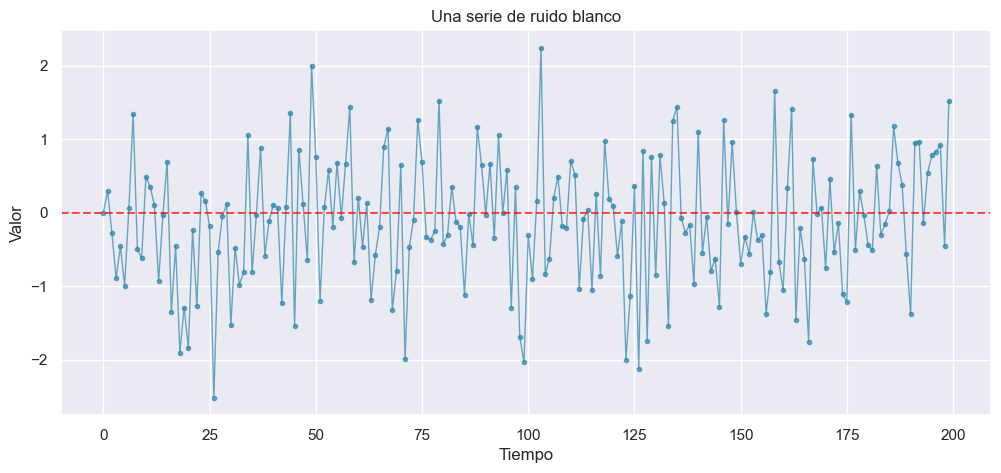

In [21]:
rng = np.random.default_rng(7)
ruido = rng.normal(loc=0, scale=1, size=200)

plt.plot(ruido, marker="o", markersize=3, linewidth=1, alpha=0.7, color="#2E86AB")
plt.axhline(0, color="red", linestyle="--", alpha=0.7)
plt.title("Una serie de ruido blanco")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()

<div style="background-color:#EAF4FB; border-left:5px solid #2E86AB; padding:12px 16px; border-radius:4px; margin:8px 0;">

**💡 Idea clave — mirando hacia adelante**

El ruido blanco es la meta implícita de todo modelo de series de tiempo: si un modelo captura toda la estructura predecible de una serie, lo que le queda por explicar (el residuo) debería *parecerse* a ruido blanco. Si después de ajustar un modelo los residuos todavía muestran patrones temporales claros, es una señal de que el modelo no capturó toda la información disponible en el pasado. Diagnosticar esto con rigor requiere una herramienta que todavía no hemos visto: la **autocorrelación** — el tema del próximo notebook.

</div>

## 14. 🧠 Compruebe lo aprendido

Responda mentalmente (o por escrito) antes de revelar cada respuesta.

**1.** ¿Por qué no deberíamos mezclar aleatoriamente una serie temporal antes de analizarla?

<details>
<summary>🔎 Ver respuesta</summary>

Porque el orden de las observaciones contiene información sobre la dependencia temporal (tendencia, estacionalidad, tramos de variabilidad similar). Mezclar los valores conserva la media y la varianza, pero destruye esa estructura — como vimos en la sección 0 con la inflación.

</details>

**2.** Una empresa quiere estimar sus ventas de los próximos tres meses. ¿Qué tipo de problema es?

<details>
<summary>🔎 Ver respuesta</summary>

Forecasting: se busca predecir valores futuros de la serie.

</details>

**3.** Un sensor industrial registra una lectura extremadamente distinta de su patrón habitual. ¿Qué tipo de problema analítico podría plantearse?

<details>
<summary>🔎 Ver respuesta</summary>

Detección de anomalías: identificar si esa lectura representa un comportamiento inusual (posible falla del sensor o del proceso que mide).

</details>

**4.** Una serie muestra picos cada diciembre, año tras año. ¿Qué componente de la serie parece estar presente?

<details>
<summary>🔎 Ver respuesta</summary>

Estacionalidad: un patrón que se repite en intervalos fijos asociados al calendario (en este caso, anual).

</details>

**5.** ¿Por qué debe definirse el horizonte de pronóstico antes de seleccionar un modelo?

<details>
<summary>🔎 Ver respuesta</summary>

Porque el horizonte, junto con la frecuencia de la serie, determina qué tan lejos en el tiempo se necesita predecir (ver sección 5). Distintos horizontes implican distintos niveles de incertidumbre y, con frecuencia, distintos modelos son más adecuados para el corto que para el largo plazo.

</details>

## 15. 🚀 ¿Y ahora qué?

### Lo que aprendimos

- El **orden temporal contiene información** que se pierde si se ignora o se mezcla.
- Una serie observada puede entenderse como la combinación de **tendencia, estacionalidad, ciclo y componente irregular**.
- **Visualizar es una parte central del análisis**, no un paso decorativo.
- Antes de modelar hay que **definir bien el problema**: qué variable, a qué nivel, con qué frecuencia, con qué horizonte.
- El forecasting es un **proceso iterativo**, no la ejecución de un único algoritmo.

### Una disciplina con más de un siglo de historia — y que sigue evolucionando

Nada de lo que vimos hoy es nuevo. Lo que sí ha cambiado con el tiempo son las herramientas disponibles para explotarlo:

| Época | Hito | Descripción |
|---|---|---|
| 1920s | Modelos autorregresivos y descomposición (Yule, Slutsky) | Primeras ideas sobre modelos autorregresivos y la descomposición en tendencia, estacionalidad, ciclo y error. |
| 1930s–1940s | Procesos estocásticos y filtrado (Kolmogorov, Wiener) | Fundamentos de la teoría de procesos estocásticos y de las técnicas de filtrado. |
| 1960s | Filtro de Kalman y modelos de espacio de estados | Estimación en sistemas dinámicos mediante espacio de estados. |
| 1970s | Revolución Box–Jenkins (ARIMA) | El modelo ARIMA se consolida como estándar para el análisis y pronóstico de series temporales. |
| 1997 | Aparición de las LSTM | Una variante de red neuronal recurrente que mejora el modelado de dependencias de largo plazo. |
| 2000s | Big Data y machine learning | Los métodos clásicos empiezan a integrarse con machine learning. |
| 2017 | Lanzamiento de Facebook Prophet | Herramienta de código abierto que automatiza el manejo de tendencia y estacionalidad. |
| 2020s | Deep learning y análisis en tiempo real | Avances en pronóstico, detección de anomalías y modelado multivariante a gran escala. |

Todavía no hemos hablado de ARIMA, Prophet ni de redes neuronales — y no lo haremos en este notebook. Pero cada una de esas siglas es, en el fondo, una forma distinta de responder la misma pregunta que nos hicimos hoy: **¿cuánto del pasado de una serie explica su futuro?**

### Lo que viene

Hasta ahora hemos aprendido a **observar y comprender** una serie temporal: identificar sus componentes, transformarla, descomponerla, y reconocer cuándo su comportamiento estadístico es estable en el tiempo.

El siguiente paso será descubrir **cuánta información contiene el pasado sobre el presente**. Para eso necesitaremos una de las ideas más importantes del análisis de series de tiempo: la **dependencia temporal y la autocorrelación**.

Nos vemos en el próximo notebook.